# Análisis Exploratorio de Commits de GitHub

**Objetivo:** Entender los patrones de actividad de developers para predecir commits futuros.

**Preguntas a responder:**
1. ¿Cuántos commits hace un developer típico por día?
2. ¿Hay patrones por día de semana?
3. ¿Los developers tienen rachas o actividad esporádica?
4. ¿Qué features podrían ser útiles para predicción?

In [1]:
!pip install psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 871.8 kB/s eta 0:00:0000:0100:01


In [2]:
# Configuración inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [3]:
# Conexión a PostgreSQL
import os
from sqlalchemy import create_engine

# Configurar conexión (ajustar con tus credenciales locales)
DB_HOST = os.getenv('DB_HOST', 'postgres')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_USER = os.getenv('DB_USER', 'devmetrics')
DB_PASSWORD = os.getenv('DB_PASSWORD', 'devmetrics_secret')
DB_NAME = os.getenv('DB_NAME', 'devmetrics')

DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

print(f"✅ Conectado a {DB_HOST}:{DB_PORT}/{DB_NAME}")

✅ Conectado a postgres:5432/devmetrics


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import joblib
import warnings
warnings.filterwarnings('ignore')

# Cargar datos (ajustar username)
query = """
SELECT 
    u.username,
    c.committed_at::DATE as date,
    COUNT(*) as commits,
    SUM(c.additions) as total_additions,
    SUM(c.deletions) as total_deletions,
    COUNT(DISTINCT c.repository_id) as repos_touched,
    AVG(c.files_changed) as avg_files_changed
FROM analytics.commits c
JOIN auth.users u ON c.user_id = u.id
WHERE u.username = 'Lexico7890'
GROUP BY u.username, c.committed_at::DATE
ORDER BY date
"""

df = pd.read_sql(query, engine)
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Cargados {len(df)} días de actividad")
print(f"📊 Rango: {df['date'].min().date()} a {df['date'].max().date()}")
print(f"📈 Commits totales: {df['commits'].sum()}")
print(f"📊 Commits promedio: {df['commits'].mean():.2f}/día")

✅ Cargados 75 días de actividad
📊 Rango: 2025-03-30 a 2026-04-09
📈 Commits totales: 302
📊 Commits promedio: 4.03/día


In [10]:
# Features temporales
df['day_of_week'] = df['date'].dt.dayofweek
df['day_of_month'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['week_of_year'] = df['date'].dt.isocalendar().week
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_monday'] = (df['day_of_week'] == 0).astype(int)
df['is_friday'] = (df['day_of_week'] == 4).astype(int)

# Features de días desde último commit
df['days_since_last'] = df['date'].diff().dt.days.fillna(0)

# Promedios móviles (ventanas de tiempo)
df['commits_avg_3d'] = df['commits'].rolling(3, min_periods=1).mean().shift(1)
df['commits_avg_7d'] = df['commits'].rolling(7, min_periods=1).mean().shift(1)
df['commits_avg_14d'] = df['commits'].rolling(14, min_periods=1).mean().shift(1)
df['commits_avg_30d'] = df['commits'].rolling(30, min_periods=1).mean().shift(1)

# Tendencia (ratio entre promedios)
df['trend_7d_vs_30d'] = df['commits_avg_7d'] / df['commits_avg_30d']

# Features de volumen de código
df['additions_avg_7d'] = df['total_additions'].rolling(7, min_periods=1).mean().shift(1)
df['deletions_avg_7d'] = df['total_deletions'].rolling(7, min_periods=1).mean().shift(1)
df['net_change'] = df['total_additions'] - df['total_deletions']

# Días desde último commit significativo (>3 commits)
df['high_activity'] = (df['commits'] >= 3).astype(int)

# Target: commits mañana
df['commits_tomorrow'] = df['commits'].shift(-1)

# Eliminar filas sin target
df = df.dropna(subset=['commits_tomorrow'])

print(f"📊 Filas para entrenamiento: {len(df)}")

📊 Filas para entrenamiento: 74


In [11]:
# Seleccionar features (las más relevantes)
feature_cols = [
    'commits', 'commits_avg_3d', 'commits_avg_7d', 'commits_avg_14d',
    'day_of_week', 'is_weekend', 'is_monday', 'is_friday',
    'days_since_last', 'trend_7d_vs_30d', 'additions_avg_7d',
    'deletions_avg_7d', 'repos_touched', 'avg_files_changed'
]

X = df[feature_cols]
y = df['commits_tomorrow']

# Validación temporal: entrenar con primeros 80%, testear con últimos 20%
split_idx = int(len(df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Entrenar Random Forest
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Predicciones
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Métricas
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("=" * 50)
print("📊 RESULTADOS DEL MODELO")
print("=" * 50)
print(f"📈 Entrenamiento: {len(X_train)} días")
print(f"📈 Prueba: {len(X_test)} días")
print(f"\n🎯 MAE Entrenamiento: ±{mae_train:.2f} commits")
print(f"🎯 MAE Prueba: ±{mae_test:.2f} commits")
print(f"📊 R² Prueba: {r2_test:.2f}")

ValueError: Input X contains NaN.
RandomForestRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

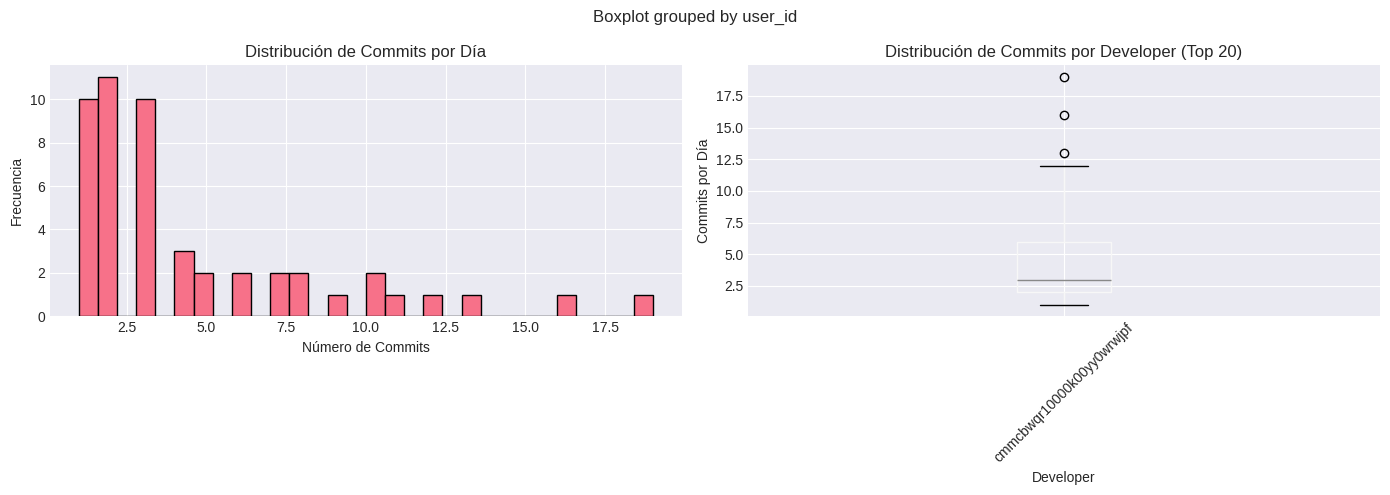

In [21]:
# Distribución de commits por día
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
df['commits'].hist(bins=30, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribución de Commits por Día')
axes[0].set_xlabel('Número de Commits')
axes[0].set_ylabel('Frecuencia')

# Boxplot por developer (top 20)
top_devs = df.groupby('user_id')['commits'].sum().nlargest(20).index
df_top = df[df['user_id'].isin(top_devs)]
df_top.boxplot(column='commits', by='user_id', ax=axes[1], rot=45)
axes[1].set_title('Distribución de Commits por Developer (Top 20)')
axes[1].set_xlabel('Developer')
axes[1].set_ylabel('Commits por Día')

plt.tight_layout()
plt.show()

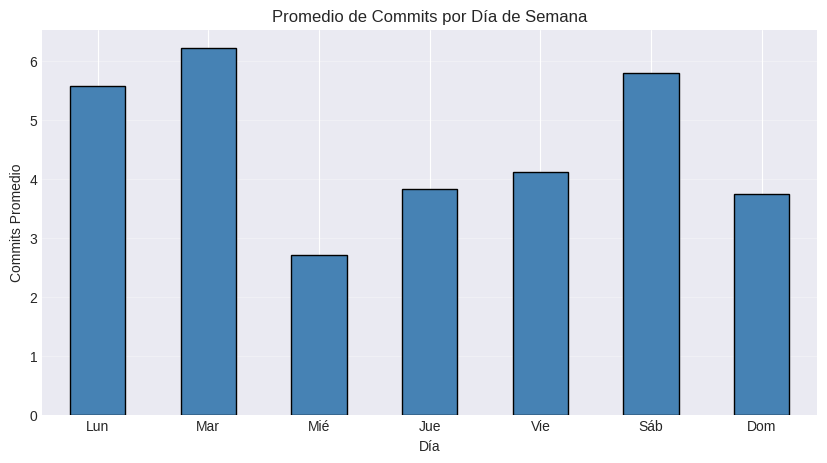

📊 Fin de semana: 4.78 commits/día
📊 Entre semana: 4.49 commits/día


In [22]:
# Patrones por día de semana
df['day_of_week'] = df['date'].dt.dayofweek
day_names = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

daily_avg = df.groupby('day_of_week')['commits'].mean()

plt.figure(figsize=(10, 5))
daily_avg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Promedio de Commits por Día de Semana')
plt.xlabel('Día')
plt.ylabel('Commits Promedio')
plt.xticks(range(7), day_names, rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"📊 Fin de semana: {daily_avg[5:7].mean():.2f} commits/día")
print(f"📊 Entre semana: {daily_avg[0:5].mean():.2f} commits/día")

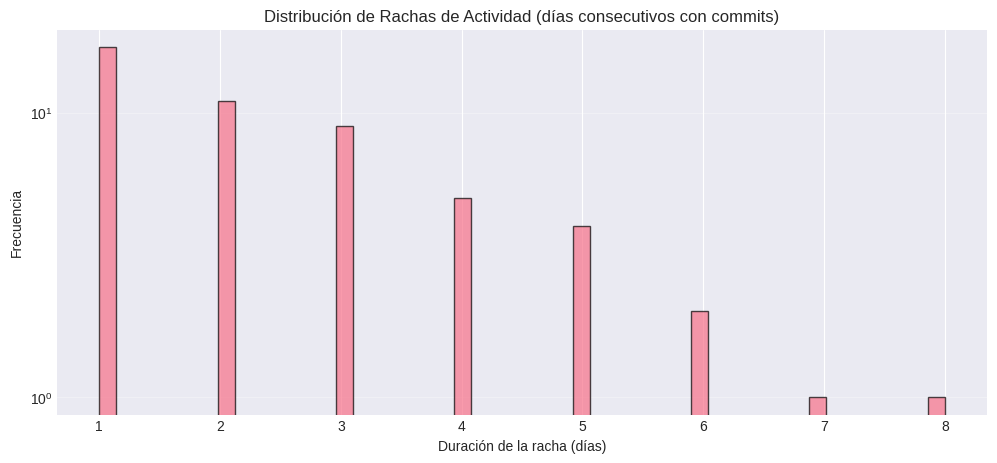

📊 Racha promedio: 2.7 días
🏆 Racha máxima: 8 días


In [25]:
# Rachas de actividad (streaks)
def compute_streak(group):
    group = group.sort_values('date')
    group['day_diff'] = group['date'].diff().dt.days
    group['streak'] = (group['day_diff'] == 1).astype(int).groupby((group['day_diff'] != 1).cumsum()).cumsum() + 1
    group['streak'] = group['streak'].fillna(1)
    return group

df_with_streak = df.groupby('user_id', group_keys=False).apply(compute_streak)

plt.figure(figsize=(12, 5))
plt.hist(df_with_streak['streak'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribución de Rachas de Actividad (días consecutivos con commits)')
plt.xlabel('Duración de la racha (días)')
plt.ylabel('Frecuencia')
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"📊 Racha promedio: {df_with_streak['streak'].mean():.1f} días")
print(f"🏆 Racha máxima: {df_with_streak['streak'].max()} días")